Loading libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3 as sql
import itertools
from siuba import _, select, group_by, summarize, filter, arrange, mutate
from plotnine import ggplot, geom_point, aes, labs, geom_line, geom_jitter, xlab, ylab, guide_legend, facet_grid, labs
import plotnine as pn

Connecting to SQLite database

In [2]:
con = sql.connect('crn.db')

Querying and plotting the results of multiple IVPs with varying rates for the production of X (XIAP or X-inhibitor of apoptosis). 

The rate for the reaction 0->X is changed from 175 to 195, and we see that the steady state for C3a (activated Caspase-3) changes. At the rates 185 and 186, we have bistability for C3a.

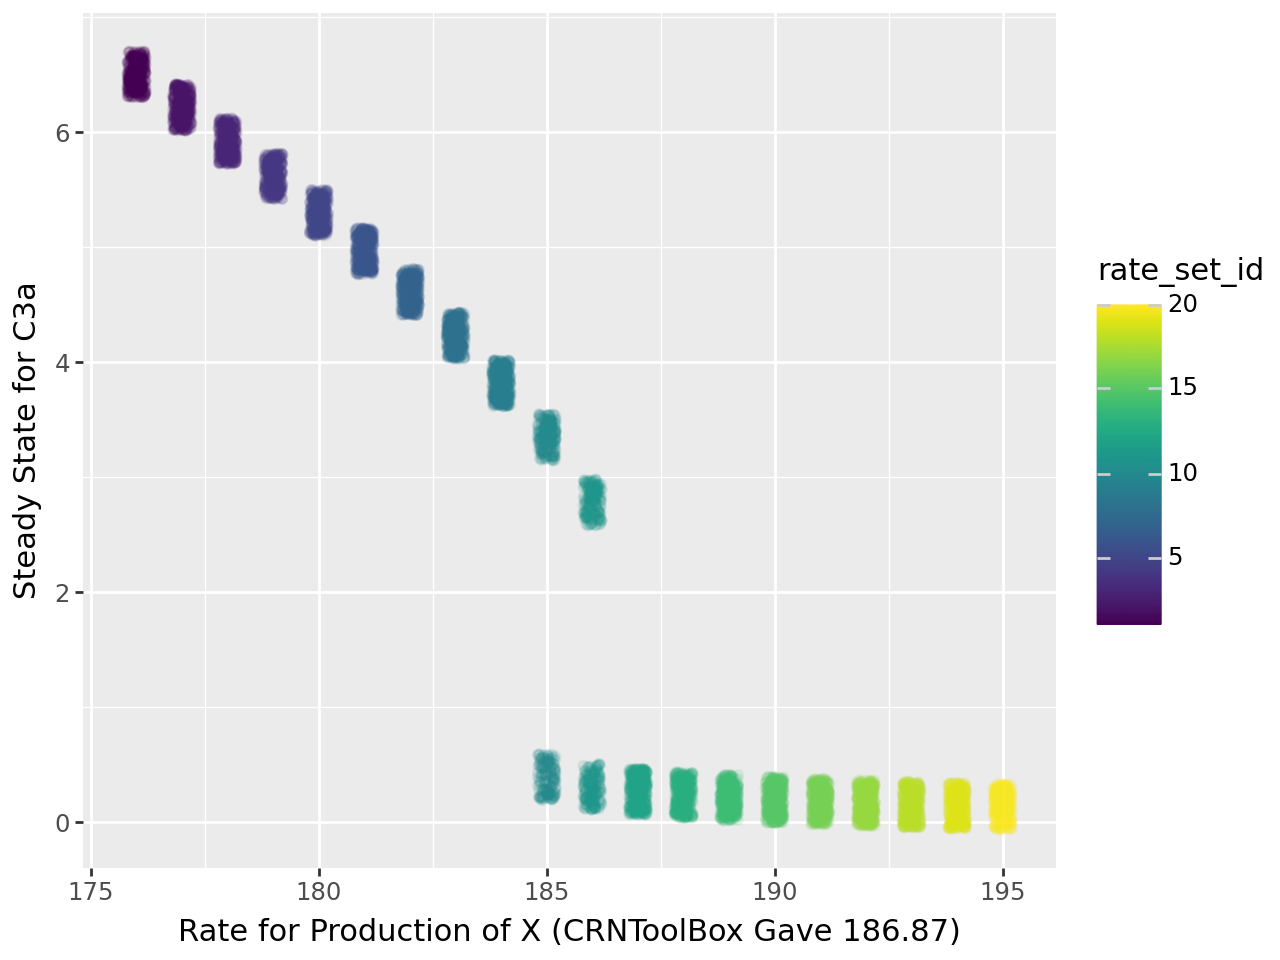

In [3]:
species_name = 'C3a'
query = f"""
SELECT rs.rate_set_id, i.ivp_id, rates.rate, sp.time, s.short_name, sp.population FROM 
Rates rates
INNER JOIN RateSets rs
ON rates.rate_set_id = rs.rate_set_id
INNER JOIN IVPs i
ON i.rate_set_id = rs.rate_set_id
INNER JOIN SpeciesPopulations sp
ON i.ivp_id = sp.ivp_id
INNER JOIN Species s
ON sp.species_id = s.species_id
WHERE reaction_id = 6
AND sp.time = 99
AND s.short_name = '{species_name}'
"""
df = pd.read_sql_query(query, con)
(df >>
 ggplot(aes(x = 'rate', y = 'population', color = 'rate_set_id'))
 + geom_jitter(height =0.2, width = 0.2, alpha = 0.1)
 + xlab('Rate for Production of X (CRNToolBox Gave 186.87)')
 + ylab(f'Steady State for {species_name}')
 )

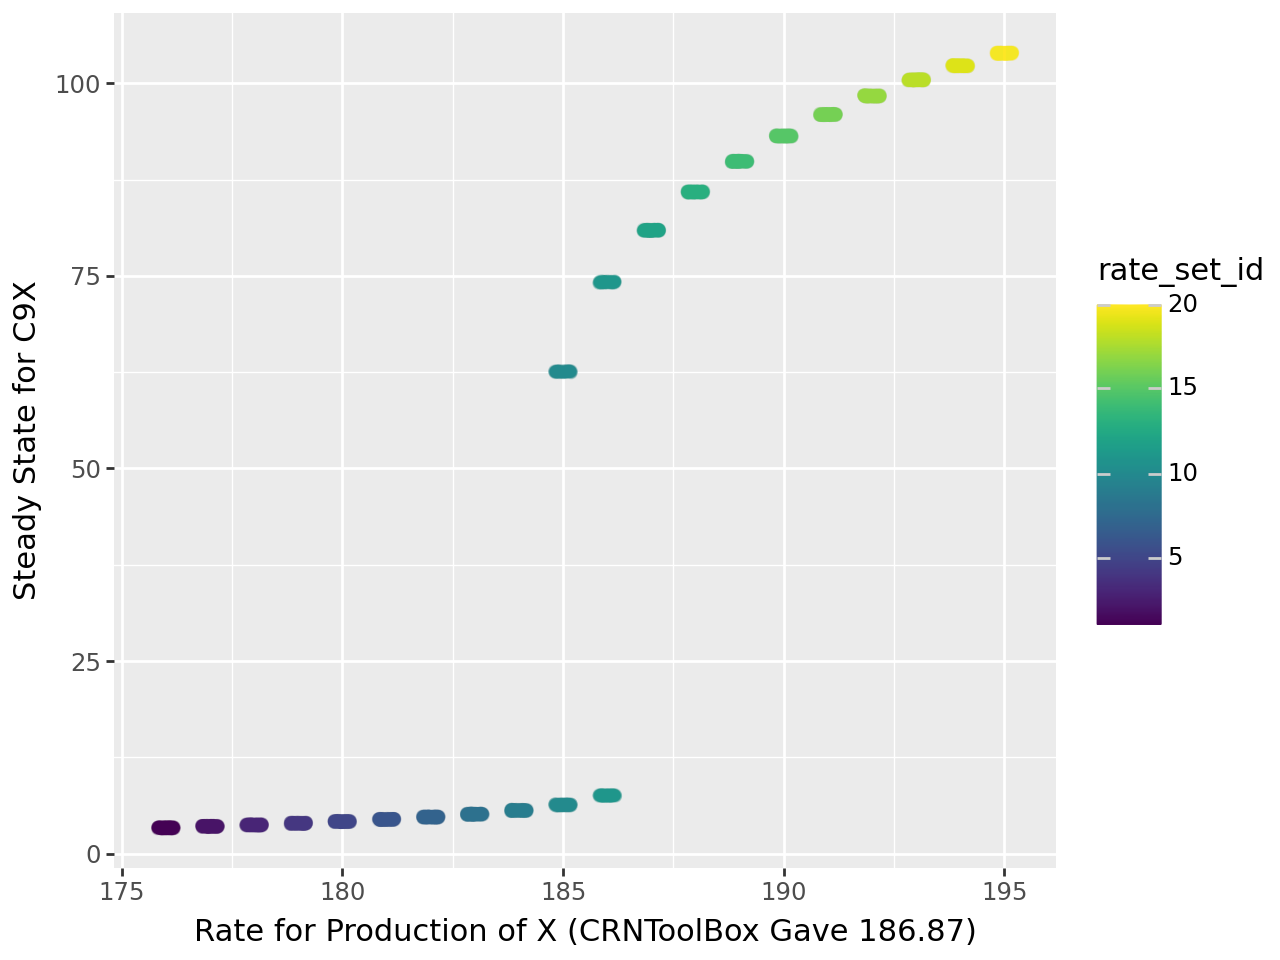

In [4]:
species_name = 'C9X'
query = f"""
SELECT rs.rate_set_id, i.ivp_id, rates.rate, sp.time, s.short_name, sp.population FROM 
Rates rates
INNER JOIN RateSets rs
ON rates.rate_set_id = rs.rate_set_id
INNER JOIN IVPs i
ON i.rate_set_id = rs.rate_set_id
INNER JOIN SpeciesPopulations sp
ON i.ivp_id = sp.ivp_id
INNER JOIN Species s
ON sp.species_id = s.species_id
WHERE reaction_id = 6
AND sp.time = 99
AND s.short_name = '{species_name}'
"""
df = pd.read_sql_query(query, con)
(df >>
 ggplot(aes(x = 'rate', y = 'population', color = 'rate_set_id'))
 + geom_jitter(height =0.2, width = 0.2, alpha = 0.1)
 + xlab('Rate for Production of X (CRNToolBox Gave 186.87)')
 + ylab(f'Steady State for {species_name}')
 )

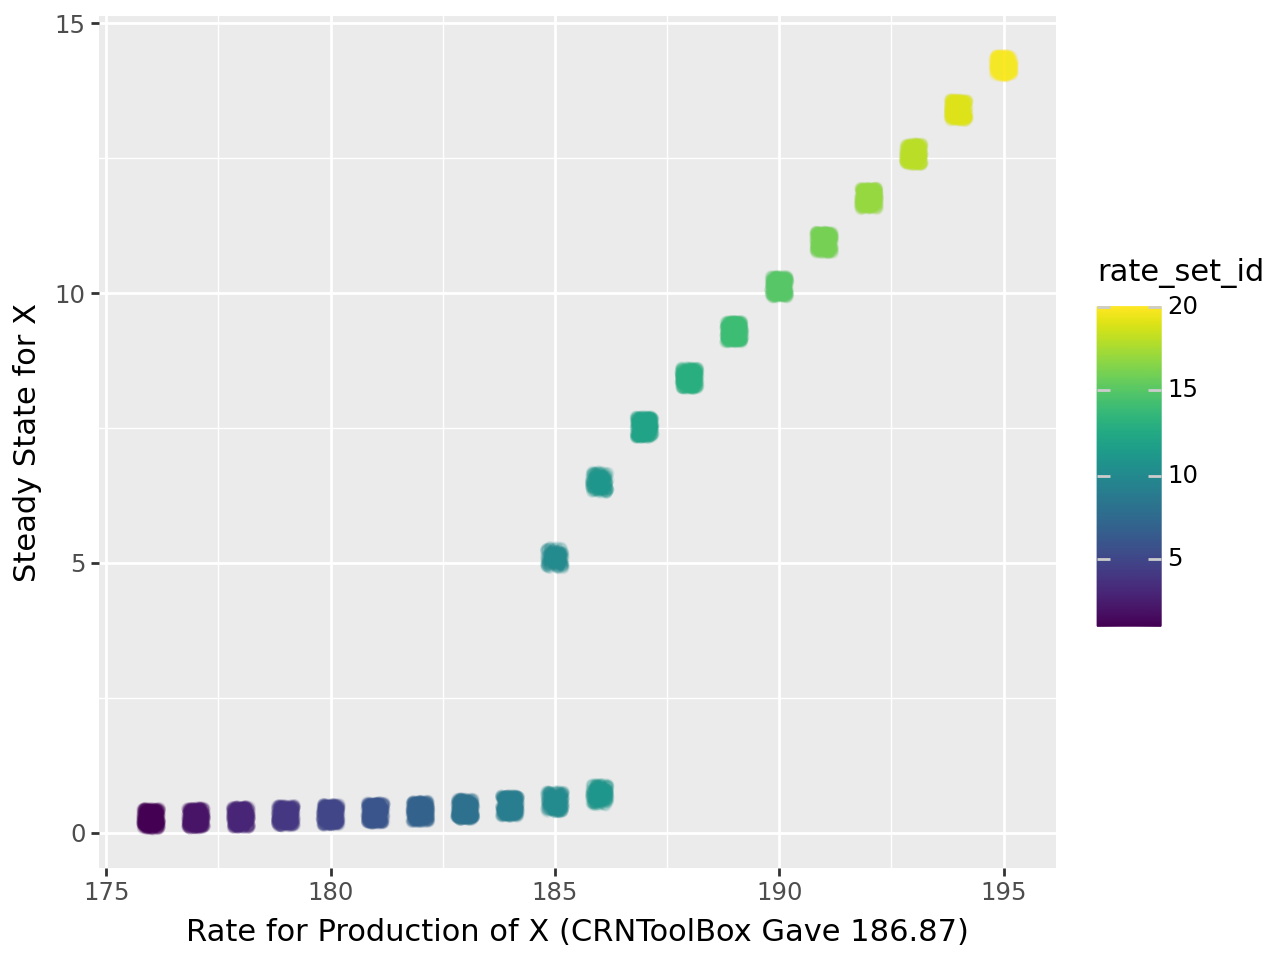

In [5]:
species_name = 'X'
query = f"""
SELECT rs.rate_set_id, i.ivp_id, rates.rate, sp.time, s.short_name, sp.population FROM 
Rates rates
INNER JOIN RateSets rs
ON rates.rate_set_id = rs.rate_set_id
INNER JOIN IVPs i
ON i.rate_set_id = rs.rate_set_id
INNER JOIN SpeciesPopulations sp
ON i.ivp_id = sp.ivp_id
INNER JOIN Species s
ON sp.species_id = s.species_id
WHERE reaction_id = 6
AND sp.time = 99
AND s.short_name = '{species_name}'
"""
df = pd.read_sql_query(query, con)
(df >>
 ggplot(aes(x = 'rate', y = 'population', color = 'rate_set_id'))
 + geom_jitter(height =0.2, width = 0.2, alpha = 0.1)
 + xlab('Rate for Production of X (CRNToolBox Gave 186.87)')
 + ylab(f'Steady State for {species_name}')
 )

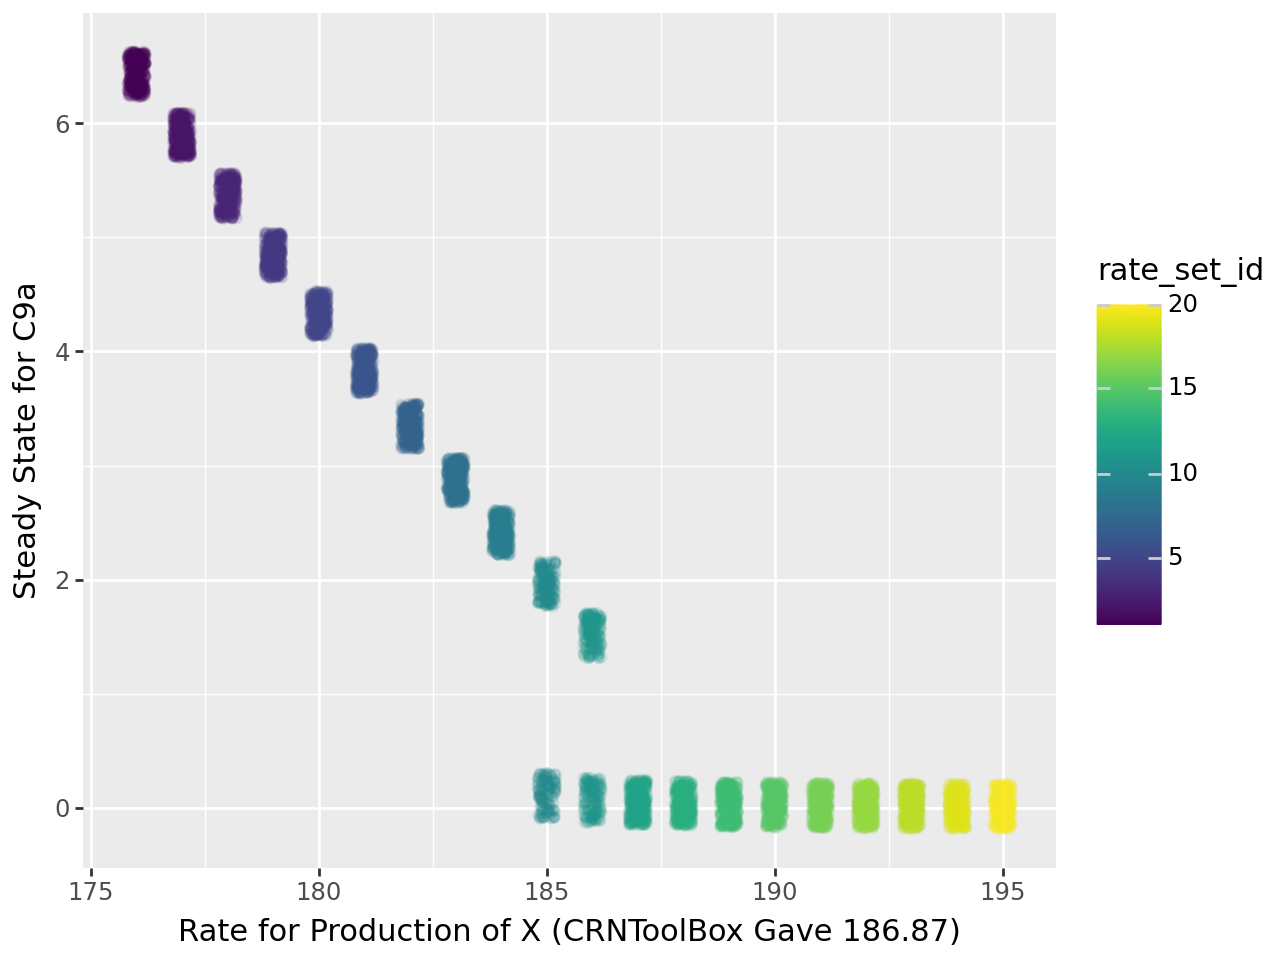

In [6]:
species_name = 'C9a'
query = f"""
SELECT rs.rate_set_id, i.ivp_id, rates.rate, sp.time, s.short_name, sp.population FROM 
Rates rates
INNER JOIN RateSets rs
ON rates.rate_set_id = rs.rate_set_id
INNER JOIN IVPs i
ON i.rate_set_id = rs.rate_set_id
INNER JOIN SpeciesPopulations sp
ON i.ivp_id = sp.ivp_id
INNER JOIN Species s
ON sp.species_id = s.species_id
WHERE reaction_id = 6
AND sp.time = 99
AND s.short_name = '{species_name}'
"""
df = pd.read_sql_query(query, con)
(df >>
 ggplot(aes(x = 'rate', y = 'population', color = 'rate_set_id'))
 + geom_jitter(height =0.2, width = 0.2, alpha = 0.1)
 + xlab('Rate for Production of X (CRNToolBox Gave 186.87)')
 + ylab(f'Steady State for {species_name}')
 )

In [7]:
species_name = 'C3a'
query = f"""
SELECT rs.rate_set_id, r.reaction_id, r.rate, sp.ivp_id, s.short_name, sp.time, sp.population FROM SpeciesPopulations sp
INNER JOIN IVPs i
ON sp.ivp_id = i.ivp_id
INNER JOIN species s
ON sp.species_id = s.species_id
INNER JOIN RateSets rs
ON i.rate_set_id = rs.rate_set_id
INNER JOIN Rates r
ON rs.rate_set_id = r.rate_set_id
WHERE r.reaction_id = 6
AND (s.short_name = '{species_name}')
"""
df = pd.read_sql_query(query, con)
df


,rate_set_id,reaction_id,rate,ivp_id,short_name,time,population
0,1,6,176.0,1,C3a,0,0.000000
1,1,6,176.0,1,C3a,1,2.874998
2,1,6,176.0,1,C3a,2,4.077716
3,1,6,176.0,1,C3a,3,5.165120
4,1,6,176.0,1,C3a,4,5.885866
...,...,...,...,...,...,...,...
721995,20,6,195.0,7220,C3a,95,0.135699
721996,20,6,195.0,7220,C3a,96,0.135699
721997,20,6,195.0,7220,C3a,97,0.135699
721998,20,6,195.0,7220,C3a,98,0.135699


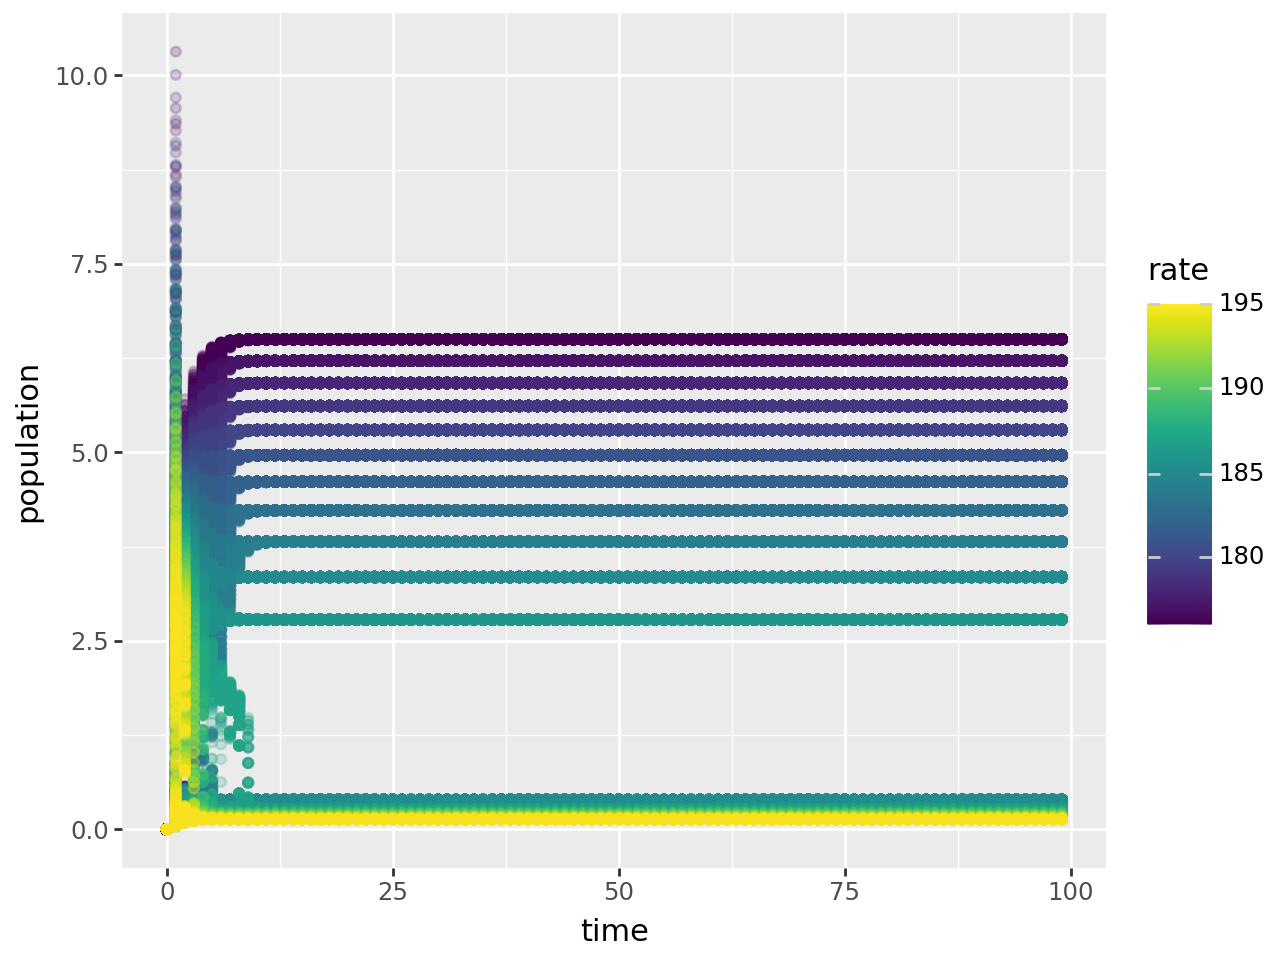

In [8]:
(df
 >> ggplot(aes(x = 'time', y = 'population', color = 'rate'))
+ geom_point(alpha = 0.2)
)

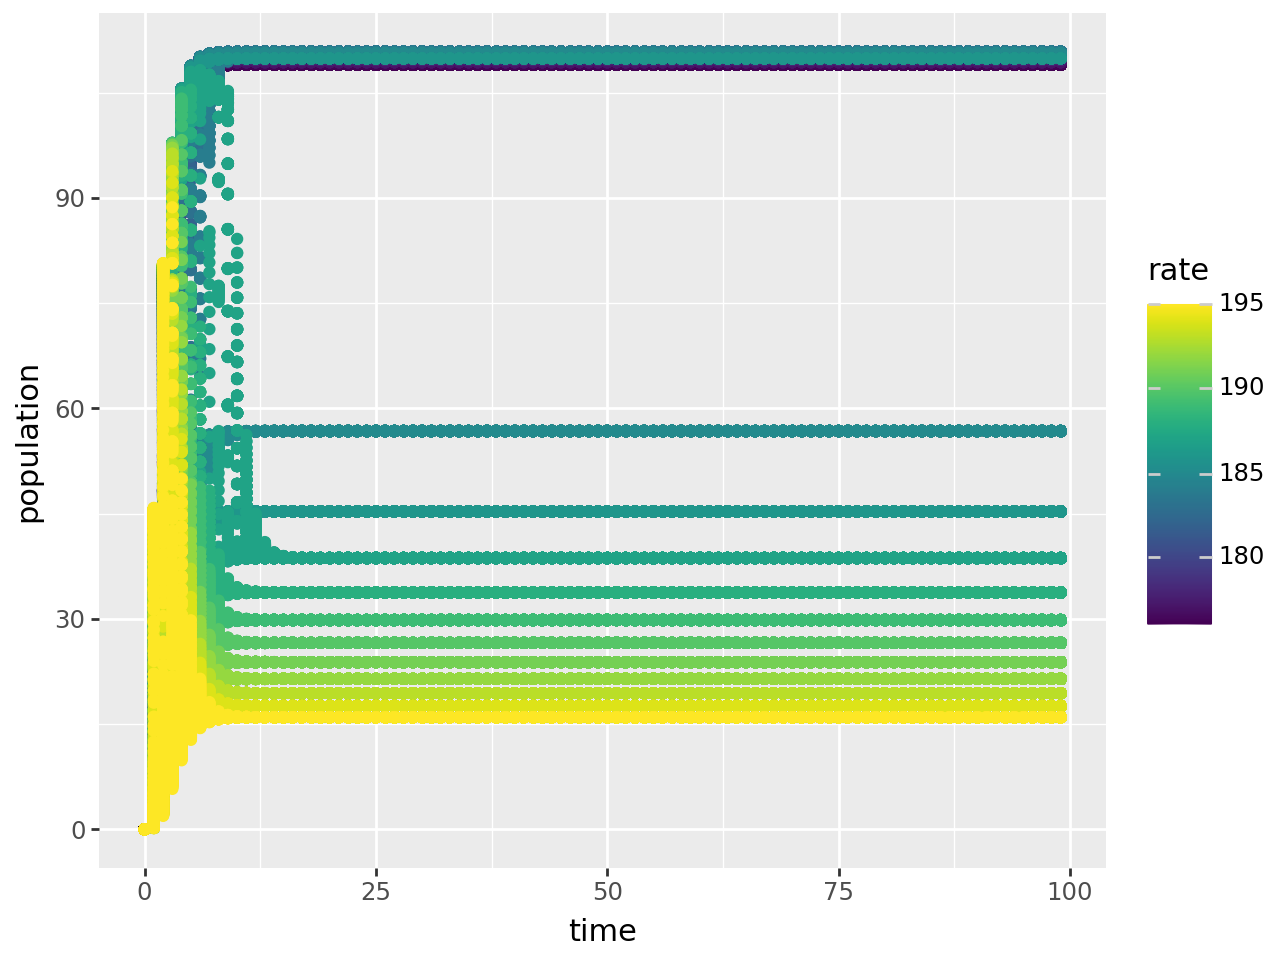

In [87]:
(df
 >> ggplot(aes(x = 'time', y = 'population', color = 'rate'))
# + geom_jitter(alpha = 0.2)
+ geom_point(alpha = 0.2)
)

Resulting steady state of C3a in IVPs with several rates of 0->X (the rates used are 176, 184, 185, 186, 187, 195)

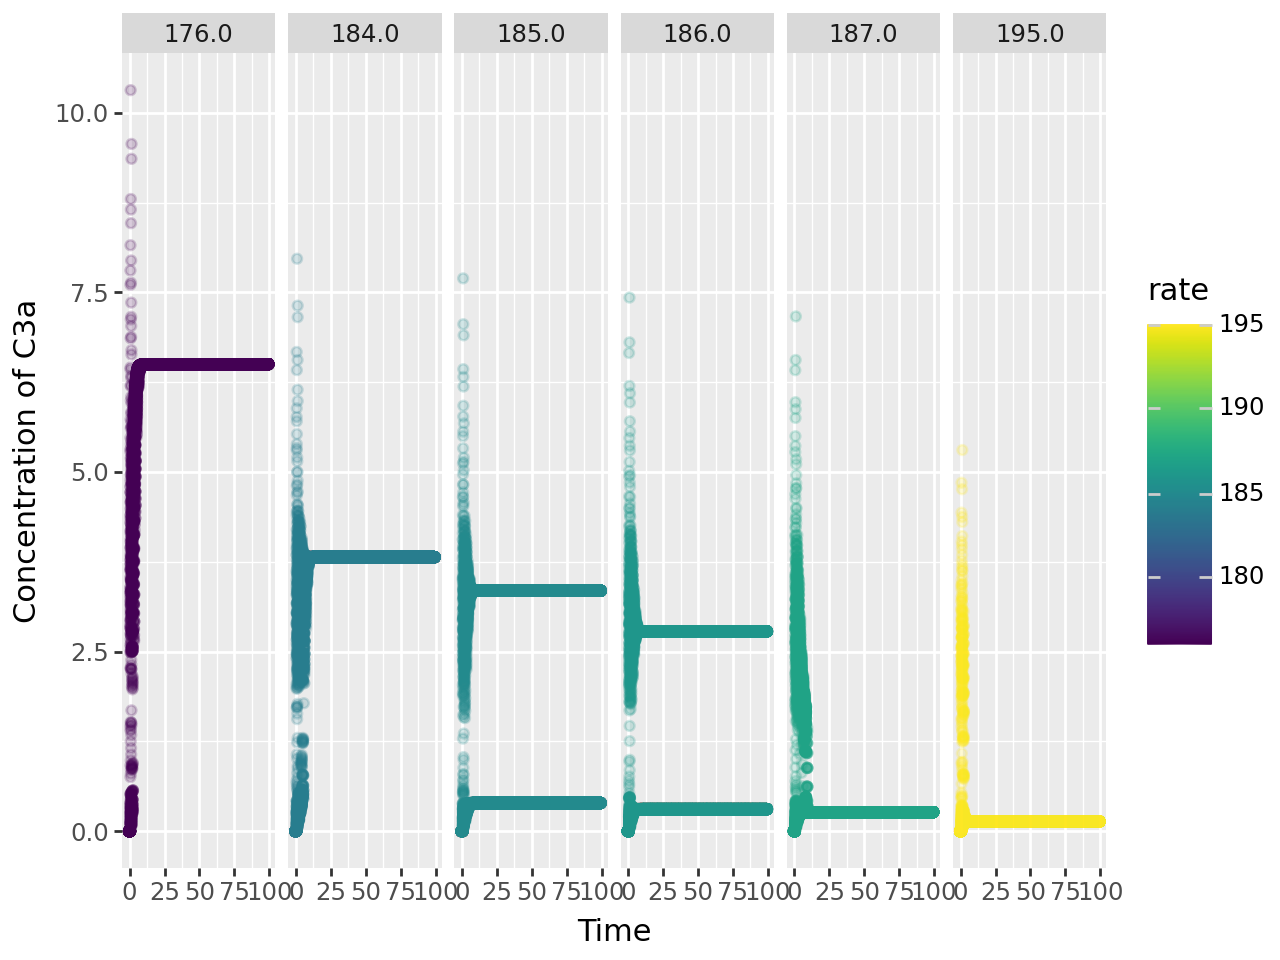

In [9]:
(df[df.rate.isin([176,184,185, 186, 187, 195])]
 >> ggplot(aes(x = 'time', y = 'population', color = 'rate'))
+ geom_jitter(alpha = 0.2)
+ facet_grid(cols = 'rate')
+ labs(x = 'Time', y = f'Concentration of {species_name}')
# + geom_point(alpha = 0.2)
)

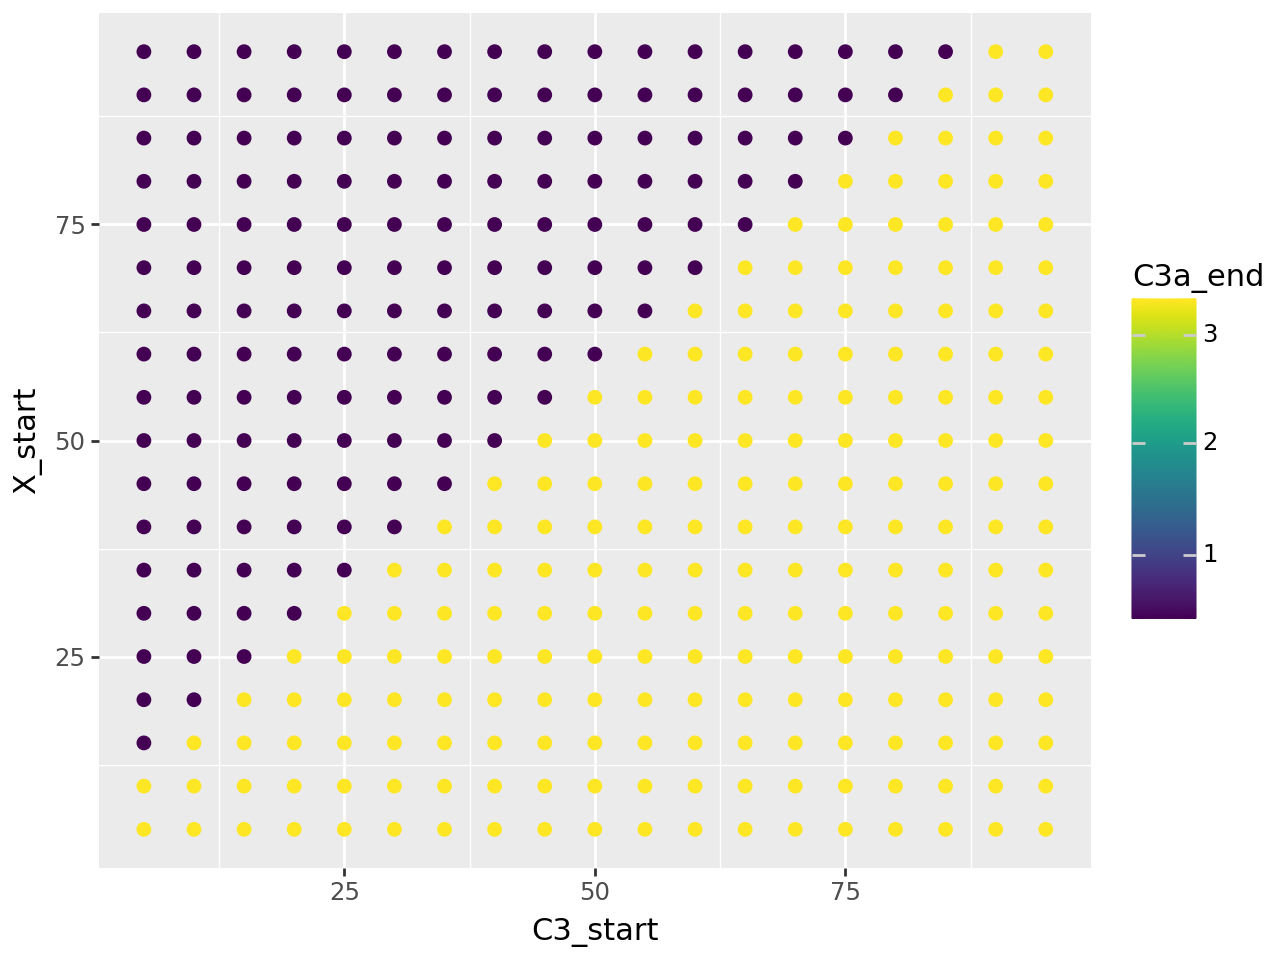

In [10]:
query = """
SELECT rs.rate_set_id, r.reaction_id, r.rate, sp.ivp_id, s.short_name, sp.time, sp.population FROM SpeciesPopulations sp
INNER JOIN IVPs i
ON sp.ivp_id = i.ivp_id
INNER JOIN species s
ON sp.species_id = s.species_id
INNER JOIN RateSets rs
ON i.rate_set_id = rs.rate_set_id
INNER JOIN Rates r
ON rs.rate_set_id = r.rate_set_id
WHERE (sp.time = 0 OR sp.time = 99)
AND r.reaction_id = 6
AND (s.short_name = 'X' OR s.short_name = 'C3a' OR s.short_name = 'C3')
AND rs.rate_set_id = 10
"""
df = pd.read_sql_query(query, con)
df
c3_0 = (df >> 
       filter(_.short_name == 'C3', _.time == 0)).reset_index()
x_0 = (df >> 
       filter(_.short_name == 'X', _.time == 0)).reset_index()
c3a_99 = (df >> 
       filter(_.short_name == 'C3a', _.time == 99)).reset_index()

plotting_df = pd.DataFrame({
    'C3_start':c3_0.population,
    'X_start': x_0.population,
    'C3_start_log10': np.log10(c3_0.population),
    'X_start_log10': np.log10(x_0.population),
    'C3a_end': c3a_99.population
})


(plotting_df
 >> ggplot(aes(x = 'C3_start', y = 'X_start', color = 'C3a_end'))
+ geom_point(size = 2)
)